In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gait_dataset.csv')

# Separate feature columns from metadata
meta_cols    = ['subject', 'label', 'num_strides']
feature_cols = [c for c in df.columns if c not in meta_cols]

park_df = df[df.label == 1]
ctrl_df = df[df.label == 0]

print("=== BASIC INFO ===")
print(f"Total subjects:       {len(df)}")
print(f"Parkinson's:          {len(park_df)}")
print(f"Healthy:              {len(ctrl_df)}")
print(f"Features:             {len(feature_cols)}")
print(f"Any missing values:   {df[feature_cols].isnull().sum().sum()}")

=== BASIC INFO ===
Total subjects:       31
Parkinson's:          15
Healthy:              16
Features:             31
Any missing values:   0


In [4]:
# Step 1: Mean comparison table
print("\nMEAN VALUES — Parkinson's vs Healthy ")
comparison = pd.DataFrame({
    "Parkinsons": park_df[feature_cols].mean(),
    "Healthy":    ctrl_df[feature_cols].mean(),
})
comparison["Difference"]     = (comparison["Parkinsons"] - comparison["Healthy"]).round(4)
comparison["Pct_Difference"] = ((comparison["Difference"] / comparison["Healthy"]) * 100).round(2)
comparison = comparison.round(4)
print(comparison.to_string())
comparison.to_csv('eda_mean_comparison.csv')
print("\nSaved eda_mean_comparison.csv")


=== MEAN VALUES — Parkinson's vs Healthy ===
                            Parkinsons  Healthy  Difference  Pct_Difference
left_stride_interval_mean       1.1421   1.0976      0.0445            4.05
left_stride_interval_std        0.2252   0.0494      0.1759          356.30
right_stride_interval_mean      1.1371   1.0970      0.0401            3.66
right_stride_interval_std       0.1927   0.0448      0.1478          329.77
left_swing_sec_mean             0.3744   0.3969     -0.0225           -5.67
left_swing_sec_std              0.0428   0.0192      0.0236          122.96
right_swing_sec_mean            0.3690   0.3908     -0.0217           -5.55
right_swing_sec_std             0.0543   0.0209      0.0334          159.90
left_swing_pct_mean            33.2843  36.1721     -2.8878           -7.98
left_swing_pct_std              2.9377   1.4215      1.5162          106.66
right_swing_pct_mean           32.6906  35.6058     -2.9152           -8.19
right_swing_pct_std             3.0616   1

In [5]:
print("\n OUTLIER CHECK (values beyond 3 std from mean) ")
for col in feature_cols:
    mean = df[col].mean()
    std  = df[col].std()
    outliers = df[abs(df[col] - mean) > 3 * std]
    if len(outliers) > 0:
        print(f"  {col}: {len(outliers)} outlier(s) — subjects: {list(outliers['subject'])}")


=== OUTLIER CHECK (values beyond 3 std from mean) ===
  left_stride_interval_std: 1 outlier(s) — subjects: ['park11']
  right_stride_interval_std: 1 outlier(s) — subjects: ['park11']
  left_swing_sec_mean: 1 outlier(s) — subjects: ['control15']
  right_swing_sec_std: 1 outlier(s) — subjects: ['park14']
  right_swing_pct_std: 1 outlier(s) — subjects: ['park14']
  left_stance_sec_std: 1 outlier(s) — subjects: ['park11']
  right_stance_sec_std: 1 outlier(s) — subjects: ['park11']
  right_stance_pct_std: 1 outlier(s) — subjects: ['park14']
  double_support_sec_mean: 1 outlier(s) — subjects: ['park11']
  double_support_sec_std: 1 outlier(s) — subjects: ['park11']
  double_support_pct_std: 1 outlier(s) — subjects: ['park14']
  stride_asymmetry: 1 outlier(s) — subjects: ['park11']
  overall_stride_variability: 1 outlier(s) — subjects: ['park11']
  double_support_variability: 1 outlier(s) — subjects: ['park14']


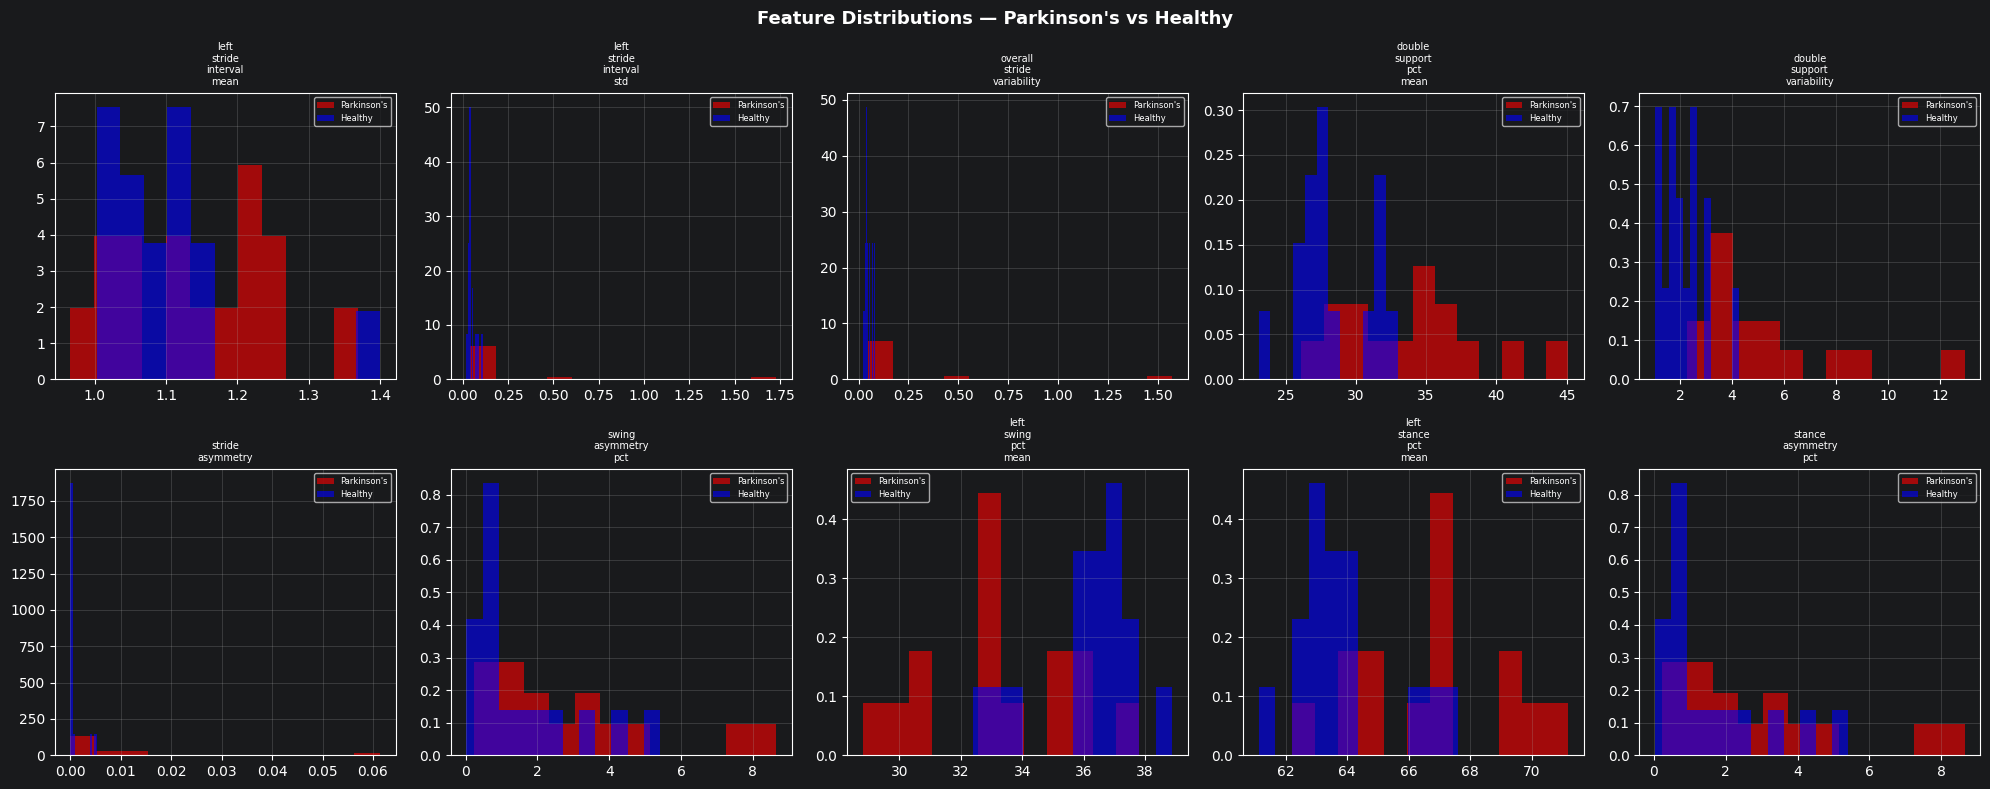

Saved eda_plot1_distributions.png


In [6]:
# Step 3: Distribution plots
# Most important features to visualize
key_features = [
    'left_stride_interval_mean',
    'left_stride_interval_std',
    'overall_stride_variability',
    'double_support_pct_mean',
    'double_support_variability',
    'stride_asymmetry',
    'swing_asymmetry_pct',
    'left_swing_pct_mean',
    'left_stance_pct_mean',
    'stance_asymmetry_pct',
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    park_vals = park_df[feature].values
    ctrl_vals = ctrl_df[feature].values

    axes[i].hist(park_vals, bins=12, alpha=0.6,
                 color='red',  label="Parkinson's", density=True)
    axes[i].hist(ctrl_vals, bins=12, alpha=0.6,
                 color='blue', label='Healthy',     density=True)
    axes[i].set_title(feature.replace('_', '\n'), fontsize=7)
    axes[i].legend(fontsize=6)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Feature Distributions — Parkinson's vs Healthy",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plot1_distributions.png', dpi=150)
plt.show()
print("Saved eda_plot1_distributions.png")


C:\Users\User\AppData\Local\Temp\ipykernel_5764\1471914184.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_5764\1471914184.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_5764\1471914184.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_5764\1471914184.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i

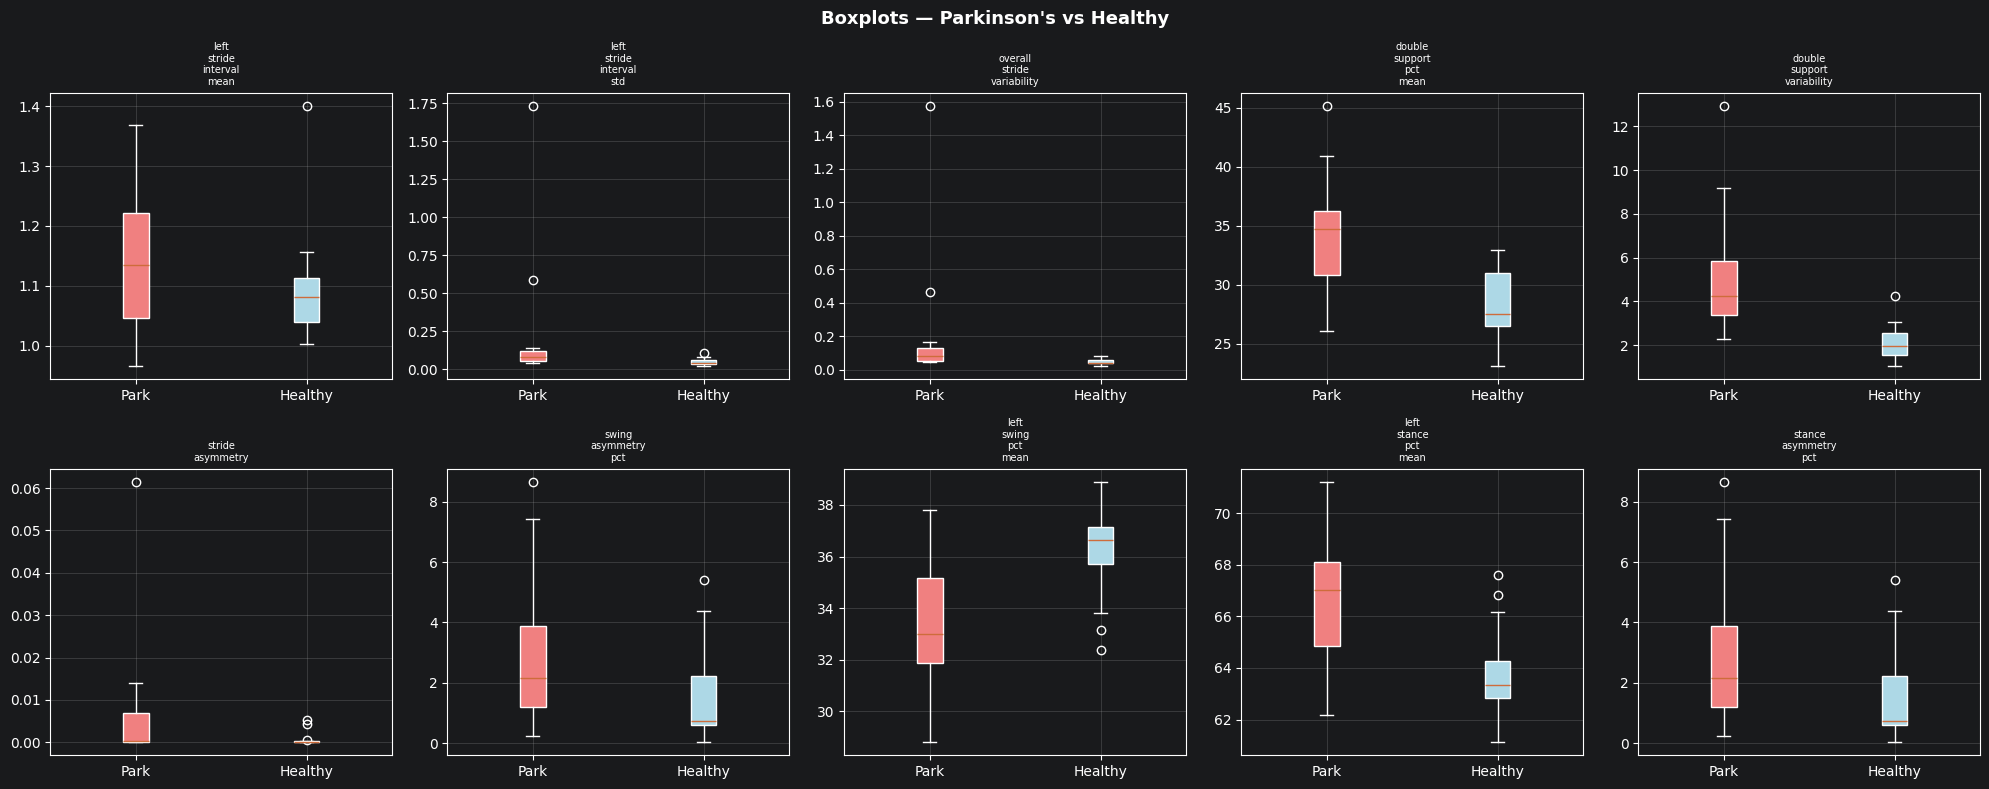

Saved eda_plot2_boxplots.png


In [7]:
# Step 4: Boxplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    park_vals = park_df[feature].values
    ctrl_vals = ctrl_df[feature].values

    bp = axes[i].boxplot(
        [park_vals, ctrl_vals],
        patch_artist=True,
        labels=["Park", "Healthy"]
    )
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
    axes[i].set_title(feature.replace('_', '\n'), fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Boxplots — Parkinson's vs Healthy",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plot2_boxplots.png', dpi=150)
plt.show()
print("Saved eda_plot2_boxplots.png")


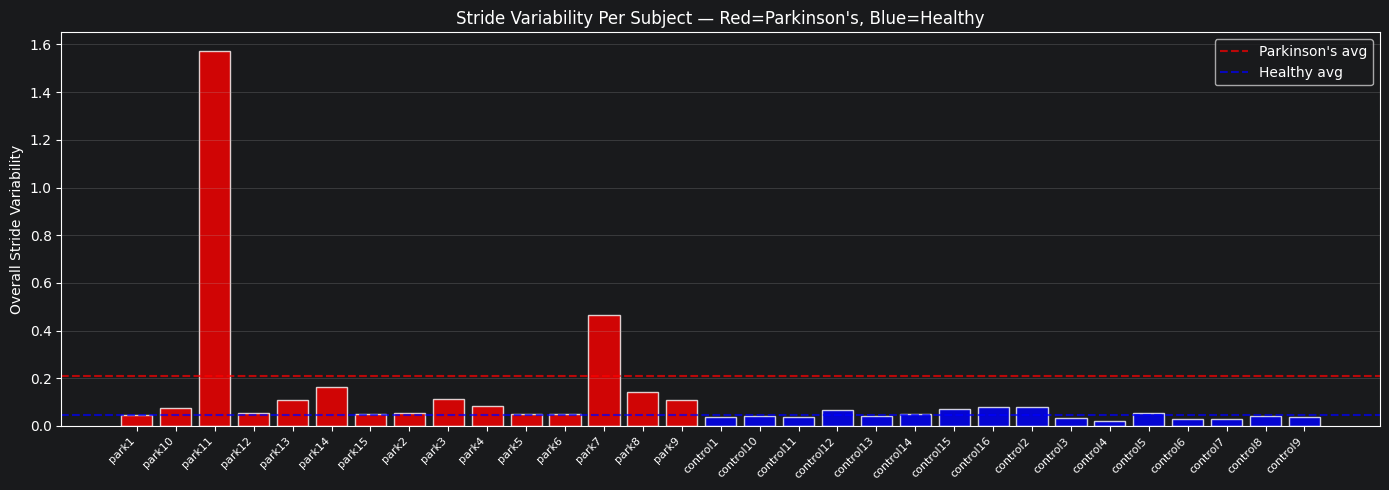

Saved eda_plot3_variability.png


In [8]:
#  Step 5: Variability per subject bar chart
plt.figure(figsize=(14, 5))
colors = df['label'].map({1: 'red', 0: 'blue'})
bars = plt.bar(df['subject'], df['overall_stride_variability'],
               color=colors, alpha=0.8, edgecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Overall Stride Variability')
plt.title("Stride Variability Per Subject — Red=Parkinson's, Blue=Healthy")
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=df[df.label==1]['overall_stride_variability'].mean(),
            color='red', linestyle='--', alpha=0.7, label="Parkinson's avg")
plt.axhline(y=df[df.label==0]['overall_stride_variability'].mean(),
            color='blue', linestyle='--', alpha=0.7, label='Healthy avg')
plt.legend()
plt.tight_layout()
plt.savefig('eda_plot3_variability.png', dpi=150)
plt.show()
print("Saved eda_plot3_variability.png")

In [9]:
# Step 6: Correlation heatmap

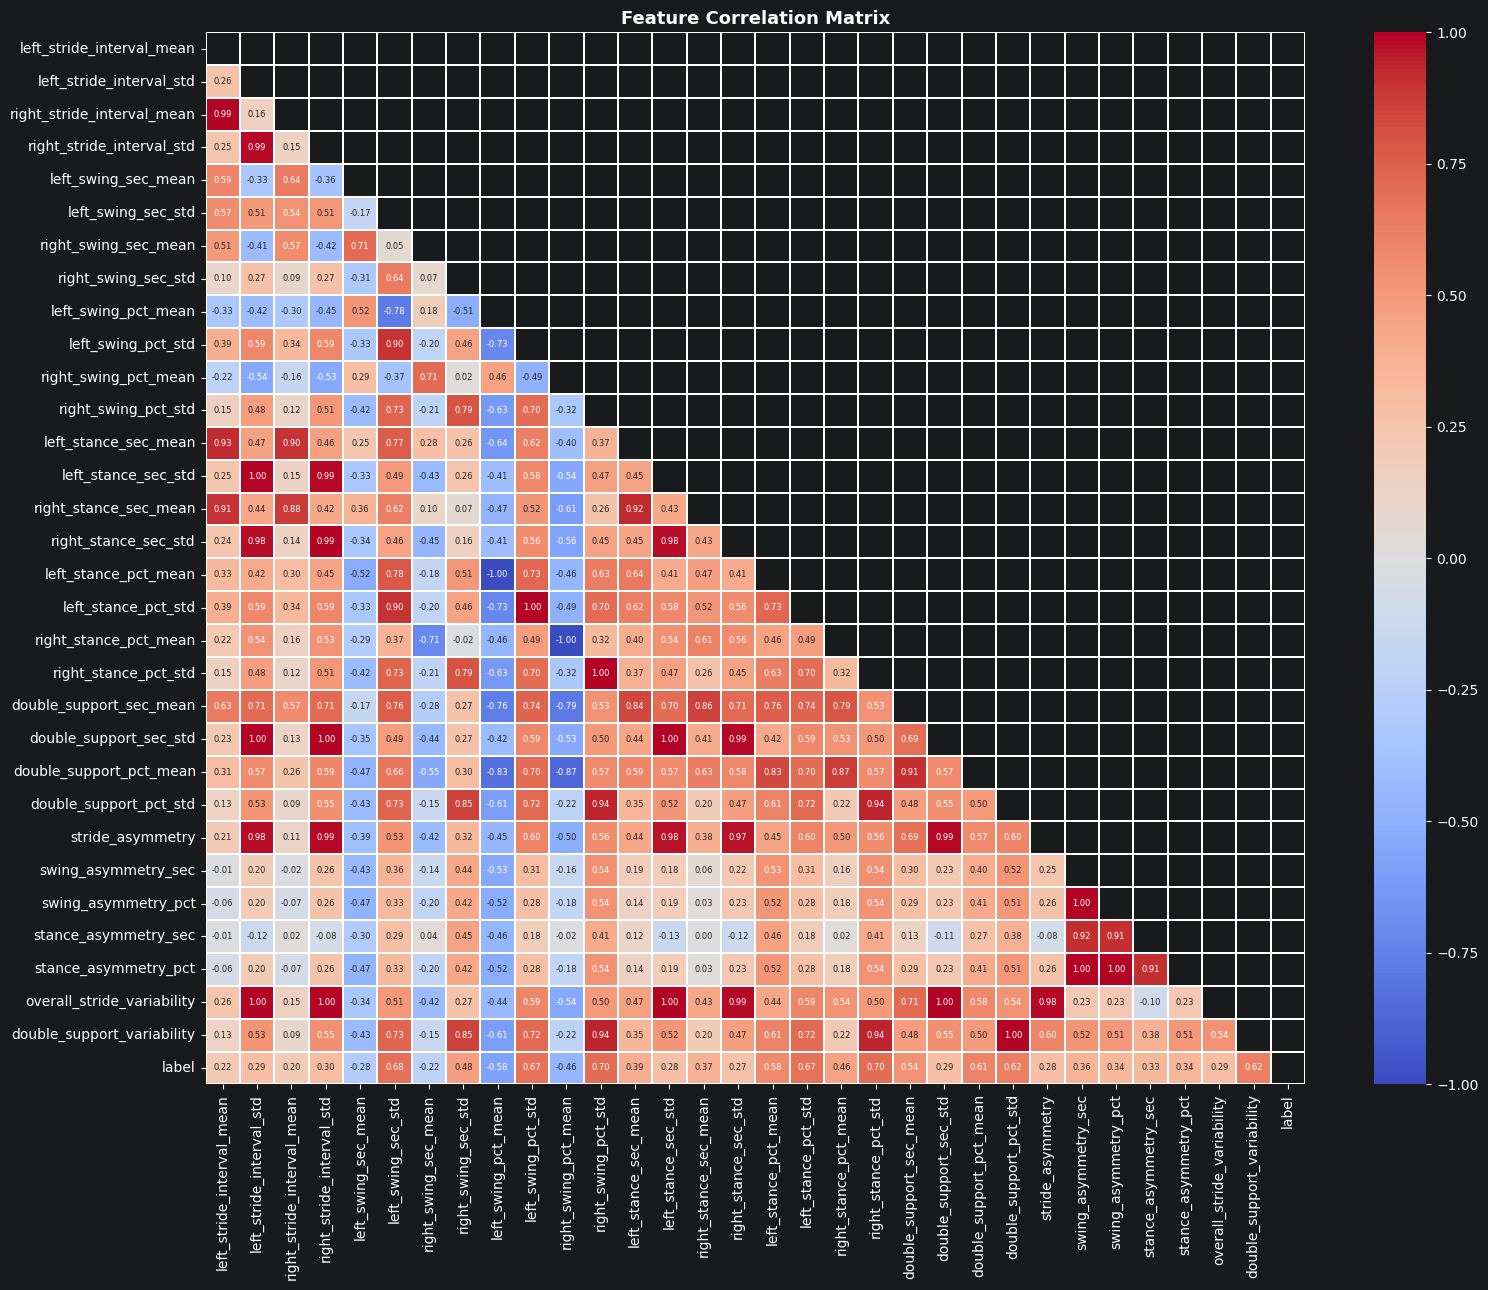

Saved eda_plot4_correlation.png


In [10]:
plt.figure(figsize=(16, 13))
corr = df[feature_cols + ['label']].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.3, annot_kws={'size': 6})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plot4_correlation.png', dpi=150)
plt.show()
print("Saved eda_plot4_correlation.png")


=== CORRELATION WITH LABEL (most predictive features) ===
right_swing_pct_std           0.7010
right_stance_pct_std          0.7010
left_swing_sec_std            0.6833
left_stance_pct_std           0.6719
left_swing_pct_std            0.6719
double_support_pct_std        0.6190
double_support_variability    0.6190
double_support_pct_mean       0.6062
left_stance_pct_mean          0.5766
left_swing_pct_mean           0.5766
double_support_sec_mean       0.5357
right_swing_sec_std           0.4753
right_swing_pct_mean          0.4566
right_stance_pct_mean         0.4566
left_stance_sec_mean          0.3919
right_stance_sec_mean         0.3745
swing_asymmetry_sec           0.3570
stance_asymmetry_pct          0.3381
swing_asymmetry_pct           0.3381
stance_asymmetry_sec          0.3251
right_stride_interval_std     0.3017
overall_stride_variability    0.2936
double_support_sec_std        0.2878
left_stride_interval_std      0.2862
left_swing_sec_mean           0.2848
stride_asymmetry

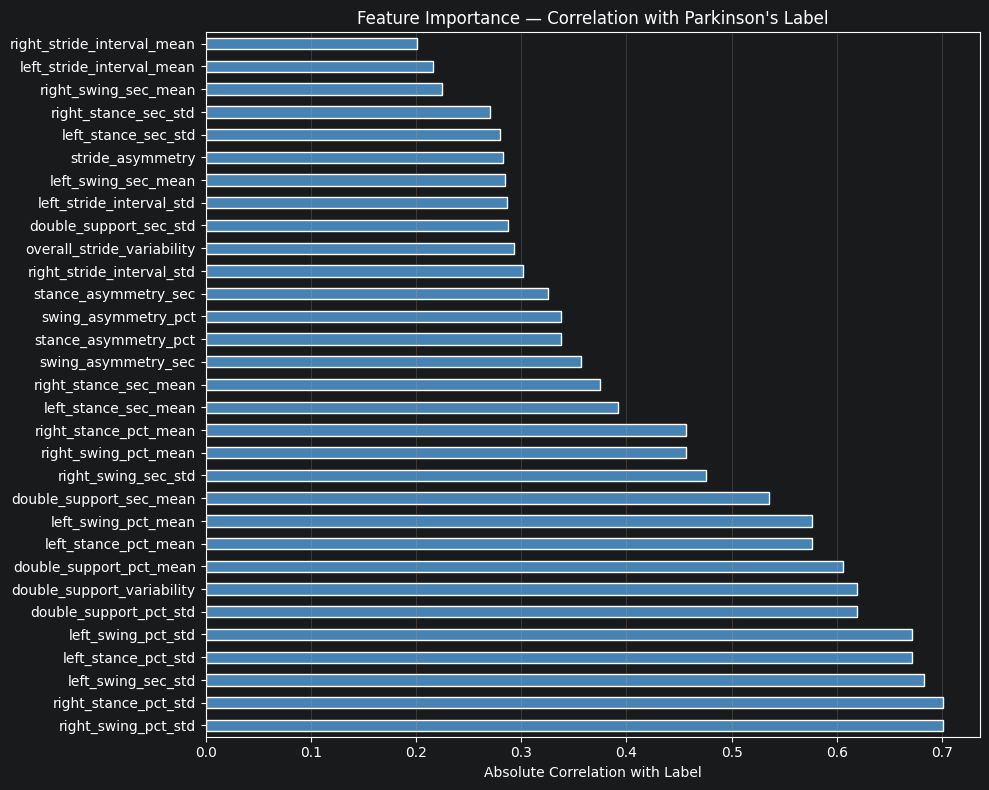

Saved eda_plot5_feature_importance.png


In [11]:
# Step 7: Correlation with label specifically
print("\n CORRELATION WITH LABEL (most predictive features) ")
label_corr = df[feature_cols + ['label']].corr()['label'].drop('label')
label_corr = label_corr.abs().sort_values(ascending=False)
print(label_corr.round(4).to_string())

plt.figure(figsize=(10, 8))
label_corr.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Absolute Correlation with Label')
plt.title('Feature Importance — Correlation with Parkinson\'s Label')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_plot5_feature_importance.png', dpi=150)
plt.show()
print("Saved eda_plot5_feature_importance.png")

Cleaning data and making it model ready


In [12]:
meta_cols    = ['subject', 'label', 'num_strides']
feature_cols = [c for c in df.columns if c not in meta_cols]

print("=== BEFORE CLEANING ===")
print(f"Subjects: {len(df)}")
print(f"park11 overall_stride_variability: "
      f"{df[df.subject=='park11']['overall_stride_variability'].values[0]:.4f}")
print(f"park14 overall_stride_variability: "
      f"{df[df.subject=='park14']['overall_stride_variability'].values[0]:.4f}")
print(f"Parkinson's avg variability: "
      f"{df[df.label==1]['overall_stride_variability'].mean():.4f}")
print(f"Healthy avg variability:     "
      f"{df[df.label==0]['overall_stride_variability'].mean():.4f}")

=== BEFORE CLEANING ===
Subjects: 31
park11 overall_stride_variability: 1.5724
park14 overall_stride_variability: 0.1625
Parkinson's avg variability: 0.2089
Healthy avg variability:     0.0471


In [13]:
#  Investigate park11 and park14
print("\n=== PARK11 vs GROUP AVERAGES ===")
park11 = df[df.subject == 'park11'][feature_cols]
park_avg = df[df.label == 1][feature_cols].mean()
ctrl_avg = df[df.label == 0][feature_cols].mean()

comparison = pd.DataFrame({
    'park11':    park11.values[0],
    'park_avg':  park_avg.values,
    'ctrl_avg':  ctrl_avg.values,
}, index=feature_cols)
comparison['park11_vs_avg'] = (
    (comparison['park11'] - comparison['park_avg']) / comparison['park_avg'] * 100
).round(1)
print(comparison.round(4).to_string())


=== PARK11 vs GROUP AVERAGES ===
                             park11  park_avg  ctrl_avg  park11_vs_avg
left_stride_interval_mean    1.2097    1.1421    1.0976            5.9
left_stride_interval_std     1.7296    0.2252    0.0494          667.9
right_stride_interval_mean   1.1483    1.1371    1.0970            1.0
right_stride_interval_std    1.4151    0.1927    0.0448          634.5
left_swing_sec_mean          0.3079    0.3744    0.3969          -17.8
left_swing_sec_std           0.0644    0.0428    0.0192           50.3
right_swing_sec_mean         0.2523    0.3690    0.3908          -31.6
right_swing_sec_std          0.0492    0.0543    0.0209           -9.4
left_swing_pct_mean         29.9758   33.2843   36.1721           -9.9
left_swing_pct_std           5.1308    2.9377    1.4215           74.7
right_swing_pct_mean        24.9740   32.6906   35.6058          -23.6
right_swing_pct_std          4.6936    3.0616    1.4401           53.3
left_stance_sec_mean         0.9019    0.76

In [14]:
#  Step 2: Winsorize outliers
# Cap extreme values at 99th percentile per feature
# This keeps the subject in the dataset but removes extreme distortion
print("\n APPLYING WINSORIZATION (cap at 99th percentile) ")

df_clean = df.copy()

for col in feature_cols:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)

    n_capped = ((df_clean[col] < p01) | (df_clean[col] > p99)).sum()
    if n_capped > 0:
        print(f"  Capping {col}: [{p01:.4f}, {p99:.4f}] — {n_capped} value(s) capped")

    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)

print("\n AFTER WINSORIZATION ")
print(f"park11 overall_stride_variability: "
      f"{df_clean[df_clean.subject=='park11']['overall_stride_variability'].values[0]:.4f}")
print(f"park14 overall_stride_variability: "
      f"{df_clean[df_clean.subject=='park14']['overall_stride_variability'].values[0]:.4f}")



=== APPLYING WINSORIZATION (cap at 99th percentile) ===
  Capping left_stride_interval_mean: [0.9763, 1.3909] — 2 value(s) capped
  Capping left_stride_interval_std: [0.0228, 1.3869] — 2 value(s) capped
  Capping right_stride_interval_mean: [0.9790, 1.3890] — 2 value(s) capped
  Capping right_stride_interval_std: [0.0229, 1.0933] — 2 value(s) capped
  Capping left_swing_sec_mean: [0.3088, 0.4906] — 2 value(s) capped
  Capping left_swing_sec_std: [0.0107, 0.0752] — 2 value(s) capped
  Capping right_swing_sec_mean: [0.2655, 0.4979] — 2 value(s) capped
  Capping right_swing_sec_std: [0.0121, 0.1702] — 2 value(s) capped
  Capping left_swing_pct_mean: [29.1555, 38.5608] — 2 value(s) capped
  Capping left_swing_pct_std: [0.7821, 4.8828] — 2 value(s) capped
  Capping right_swing_pct_mean: [26.0728, 39.2284] — 2 value(s) capped
  Capping right_swing_pct_std: [0.8933, 5.6894] — 2 value(s) capped
  Capping left_stance_sec_mean: [0.6266, 0.9518] — 2 value(s) capped
  Capping left_stance_sec_std:

In [15]:
#  Select best features for modeling
# Keep only features with correlation > 0.30 with label
# Drops weak features and reduces noise
print("\n FEATURE SELECTION ")
correlations = df_clean[feature_cols + ['label']].corr()['label'].drop('label').abs()
strong_features = correlations[correlations >= 0.30].sort_values(ascending=False)

print(f"Features with correlation >= 0.30: {len(strong_features)}")
print(strong_features.round(4).to_string())


=== FEATURE SELECTION ===
Features with correlation >= 0.30: 25
right_swing_pct_std           0.7165
right_stance_pct_std          0.7165
left_swing_sec_std            0.6907
left_stance_pct_std           0.6767
left_swing_pct_std            0.6767
double_support_pct_std        0.6363
double_support_variability    0.6363
double_support_pct_mean       0.6118
left_swing_pct_mean           0.5778
left_stance_pct_mean          0.5778
double_support_sec_mean       0.5447
right_swing_sec_std           0.4867
right_stance_pct_mean         0.4668
right_swing_pct_mean          0.4668
left_stance_sec_mean          0.3929
right_stance_sec_mean         0.3811
swing_asymmetry_sec           0.3570
stance_asymmetry_pct          0.3377
swing_asymmetry_pct           0.3377
right_stride_interval_std     0.3313
stance_asymmetry_sec          0.3247
overall_stride_variability    0.3172
double_support_sec_std        0.3108
left_stride_interval_std      0.3050
stride_asymmetry              0.3049


In [16]:
# Save two versions

# Full cleaned dataset — all features
df_clean.to_csv('gait_dataset_clean.csv', index=False)
print("\nSaved gait_dataset_clean.csv — all features, outliers capped")

# Modeling dataset — strong features only + metadata
model_cols = list(strong_features.index) + meta_cols
df_model = df_clean[model_cols]
df_model.to_csv('gait_dataset_model.csv', index=False)
print(f"Saved gait_dataset_model.csv — {len(strong_features)} strong features only")


Saved gait_dataset_clean.csv — all features, outliers capped
Saved gait_dataset_model.csv — 25 strong features only


In [17]:
# Final summary
print("\n FINAL DATASET READY FOR MODELING ")
print(f"Subjects:             {len(df_model)}")
print(f"Parkinson's:          {len(df_model[df_model.label==1])}")
print(f"Healthy:              {len(df_model[df_model.label==0])}")
print(f"Features selected:    {len(strong_features)}")
print(f"\nSelected features:")
for i, feat in enumerate(strong_features.index, 1):
    print(f"  {i:2}. {feat} (corr={strong_features[feat]:.3f})")


=== FINAL DATASET READY FOR MODELING ===
Subjects:             31
Parkinson's:          15
Healthy:              16
Features selected:    25

Selected features:
   1. right_swing_pct_std (corr=0.716)
   2. right_stance_pct_std (corr=0.716)
   3. left_swing_sec_std (corr=0.691)
   4. left_stance_pct_std (corr=0.677)
   5. left_swing_pct_std (corr=0.677)
   6. double_support_pct_std (corr=0.636)
   7. double_support_variability (corr=0.636)
   8. double_support_pct_mean (corr=0.612)
   9. left_swing_pct_mean (corr=0.578)
  10. left_stance_pct_mean (corr=0.578)
  11. double_support_sec_mean (corr=0.545)
  12. right_swing_sec_std (corr=0.487)
  13. right_stance_pct_mean (corr=0.467)
  14. right_swing_pct_mean (corr=0.467)
  15. left_stance_sec_mean (corr=0.393)
  16. right_stance_sec_mean (corr=0.381)
  17. swing_asymmetry_sec (corr=0.357)
  18. stance_asymmetry_pct (corr=0.338)
  19. swing_asymmetry_pct (corr=0.338)
  20. right_stride_interval_std (corr=0.331)
  21. stance_asymmetry_sec 